In [1]:
import os
print(os.environ["OPENBLAS_NUM_THREADS"])
print(os.environ["OMP_NUM_THREADS"])

32
32


In [3]:
# from cuml.decomposition import PCA
# import cuml
# import cudf
from sklearn.decomposition import PCA
import umap

import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
import os
import sys
import gzip
import json
import shutil
import hashlib
import importlib
import subprocess
import warnings
import numpy as np
from IPython.display import display

pd.set_option('display.max_colwidth', None)   # 单元格内容不截断
pd.set_option('display.max_columns', None)    # 显示所有列
pd.set_option('display.width', None)          # 自动适配宽度
pd.set_option('display.max_rows', 200)        # 需要时显示更多行

/p1/zulab_users/jtian/anaconda3/envs/my_GPUumapIRISeq_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


connection_dir = Path("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/connections")

matrix_sparse = load_npz(connection_dir / "receiver_sender_connection_matrix_min_umi.npz")

receiver_barcodes = pd.read_csv(connection_dir / "receiver_barcodes.csv")["receiver_barcode"]
sender_barcodes = pd.read_csv(connection_dir / "sender_barcodes.csv")["sender_barcode"]

matrix_data_filter = pd.DataFrame(
    matrix_sparse.toarray(),
    index=receiver_barcodes.to_numpy(),
    columns=sender_barcodes.to_numpy(),
)

matrix_data_filter.index.name = "receiver_barcode"
matrix_data_filter.columns.name = "sender_barcode"


In [1]:
matrix_data_filter

NameError: name 'matrix_data_filter' is not defined

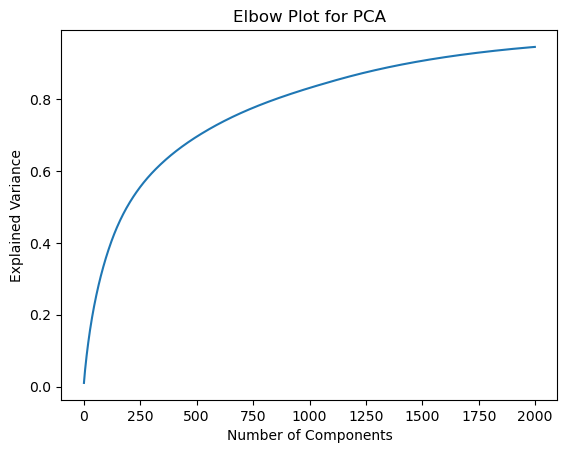

In [6]:

# Log1p transformation
matrix_data_log1p = np.log1p(matrix_data_filter)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
matrix_data_standardized = scaler.fit_transform(matrix_data_log1p)

# Perform PCA on the standardized and log-transformed data
pca = PCA(n_components=2000)
pca.fit(matrix_data_standardized)

# Plot the explained variance as a function of the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Elbow Plot for PCA')
plt.show()

In [7]:
pca = PCA(n_components=750)
matrix_data_pca = pca.fit_transform(matrix_data_standardized)


In [8]:


# Set random seed for reproducibility
SEED = 42  # Set this to your desired seed value


# Create and fit the UMAP transformer
mapper = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric='euclidean',
    random_state=SEED,
    n_epochs=50000,#500
    verbose=True, spread=.6
)
coords = mapper.fit_transform(matrix_data_pca)

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(min_dist=0.2, n_epochs=50000, n_jobs=1, n_neighbors=25, random_state=42, spread=0.6, verbose=True)
Sun Jul 12 05:57:27 2026 Construct fuzzy simplicial set
Sun Jul 12 05:57:27 2026 Finding Nearest Neighbors
Sun Jul 12 05:57:27 2026 Building RP forest with 10 trees
Sun Jul 12 05:57:32 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Sun Jul 12 05:57:45 2026 Finished Nearest Neighbor Search
Sun Jul 12 05:57:47 2026 Construct embedding


Epochs completed:   0%|            0/50000 [00:00]

	completed  0  /  50000 epochs
	completed  5000  /  50000 epochs
	completed  10000  /  50000 epochs
	completed  15000  /  50000 epochs
	completed  20000  /  50000 epochs
	completed  25000  /  50000 epochs
	completed  30000  /  50000 epochs
	completed  35000  /  50000 epochs
	completed  40000  /  50000 epochs
	completed  45000  /  50000 epochs
Sun Jul 12 06:19:42 2026 Finished embedding


/tmp/ipykernel_2492485/3171691361.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], s=s, cmap='Spectral')


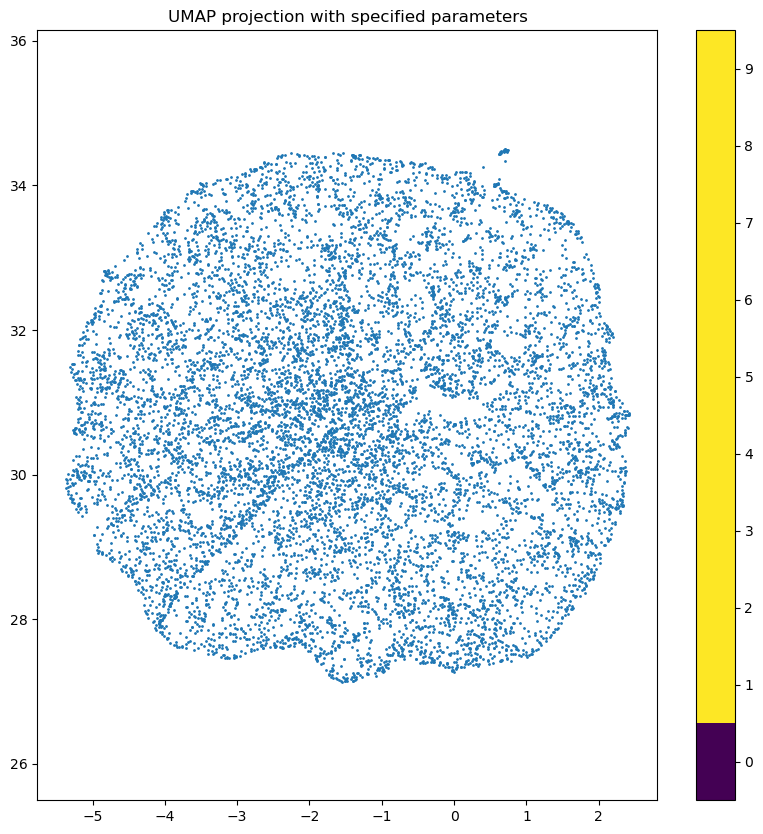

In [9]:

def plot_umap(embedding, title='UMAP Embedding', s=1, figsize=(10, 10)):
    """
    Plots UMAP embeddings.
    
    Parameters:
    - embedding: UMAP embeddings (typically from mapper.fit_transform)
    - title: Title of the plot
    - s: Size of each point
    - figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    plt.scatter(embedding[:, 0], embedding[:, 1], s=s, cmap='Spectral')
    plt.gca().set_aspect('equal', 'datalim')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(title)
    plt.show()

# To plot your coords
plot_umap(coords, title="UMAP projection with specified parameters")

In [11]:
umap_df = pd.DataFrame(coords, columns=['UMAP1','UMAP2'], index=matrix_data_filter.index)

umap_out = Path("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-cpugpu/cpu_beads_umap_coords.csv")
umap_out.parent.mkdir(parents=True, exist_ok=True)
umap_df.to_csv(
    umap_out,
    index=True,
    index_label="receiver_barcode"
)

print(f"Saved: {umap_out}")


Saved: /p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-cpugpu/cpu_beads_umap_coords.csv


In [12]:
adata=sc.read_h5ad('/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/cDNA/Adata/adata_leiden.h5ad')

In [ ]:
merge=adata.obs.merge(umap_df, left_index=True, right_index=True, how='left')

In [21]:
adata.obsm['X_umap_beads'] = merge[['UMAP1', 'UMAP2']].copy().to_numpy()

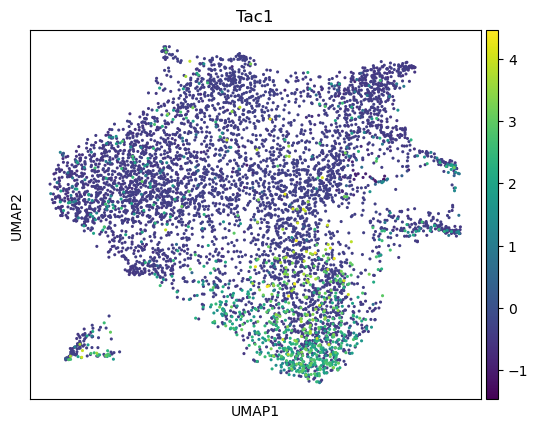

In [19]:
sc.pl.umap(adata, color=['Tac1'],gene_symbols="Gene_name")

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


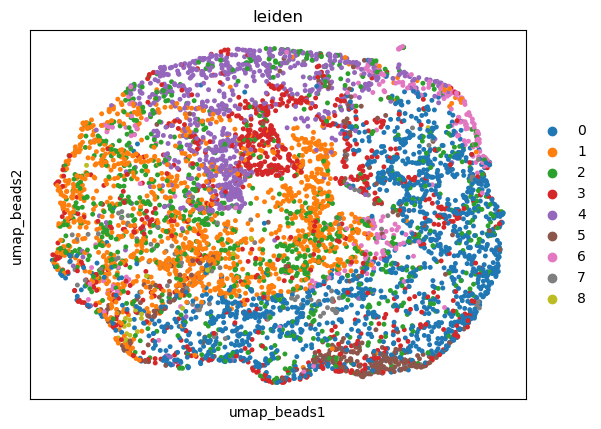

In [22]:
sc.pl.embedding(adata, basis="umap_beads", color=["leiden"], s=50)

In [23]:
adata.write_h5ad('/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-cpugpu/cpu_adata_umap_beads.h5ad')

使用GPU UMAP创建beads connection

In [2]:
connection_dir = Path("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/connections")

matrix_sparse = load_npz(connection_dir / "receiver_sender_connection_matrix_min_umi.npz")

receiver_barcodes = pd.read_csv(connection_dir / "receiver_barcodes.csv")["receiver_barcode"]
sender_barcodes = pd.read_csv(connection_dir / "sender_barcodes.csv")["sender_barcode"]

matrix_data_filter = pd.DataFrame(
    matrix_sparse.toarray(),
    index=receiver_barcodes.to_numpy(),
    columns=sender_barcodes.to_numpy(),
)

matrix_data_filter.index.name = "receiver_barcode"
matrix_data_filter.columns.name = "sender_barcode"


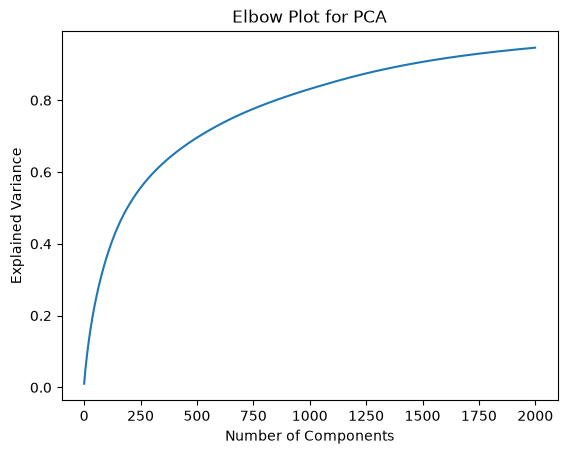

In [3]:

# Log1p transformation
matrix_data_log1p = np.log1p(matrix_data_filter)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
matrix_data_standardized = scaler.fit_transform(matrix_data_log1p)

# Perform PCA on the standardized and log-transformed data
pca = PCA(n_components=2000)
pca.fit(matrix_data_standardized)

# Plot the explained variance as a function of the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Elbow Plot for PCA')
plt.show()

In [4]:
pca = PCA(n_components=750)
matrix_data_pca = pca.fit_transform(matrix_data_standardized)


In [6]:
# Set random seed for reproducibility
SEED = 42  # Set this to your desired seed value

# Create and fit the UMAP transformer
mapper = cuml.UMAP(
    n_neighbors=20,
    min_dist=0.75,
    metric='cosine',
    random_state=SEED,
    n_epochs=20000,
    learning_rate=1.0,
    verbose=True
)
coords = mapper.fit_transform(matrix_data_pca)

[2026-07-12 08:07:26.807] [CUML] [debug] Building knn graph using build_algo='brute_force_knn'
[2026-07-12 08:07:26.824] [CUML] [debug] Computing KNN Graph
[2026-07-12 08:07:26.884] [CUML] [debug] Computing fuzzy simplicial set


/tmp/ipykernel_2504215/3171691361.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], s=s, cmap='Spectral')


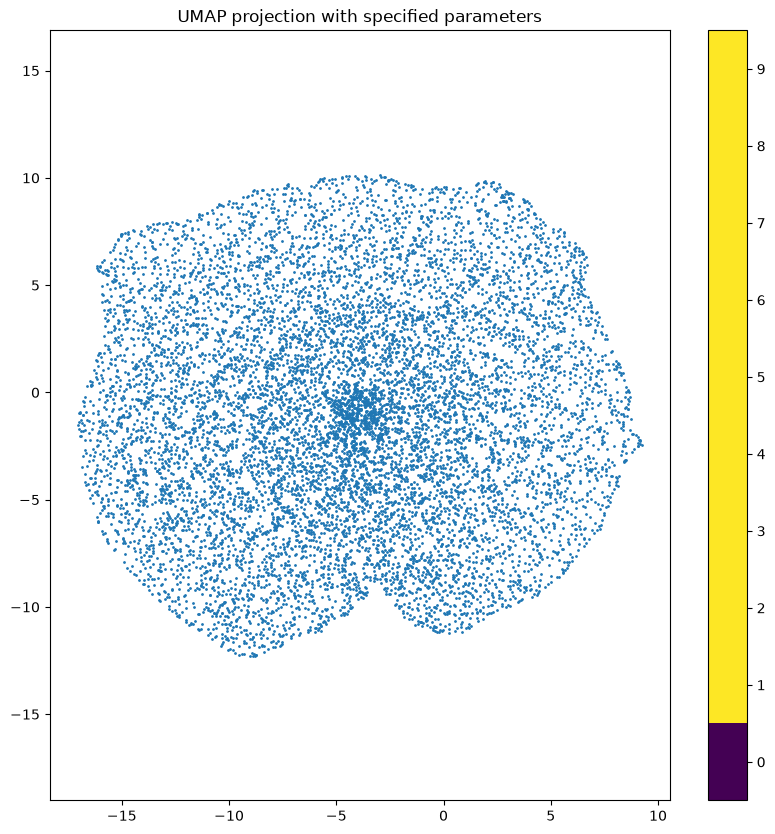

In [7]:

def plot_umap(embedding, title='UMAP Embedding', s=1, figsize=(10, 10)):
    """
    Plots UMAP embeddings.
    
    Parameters:
    - embedding: UMAP embeddings (typically from mapper.fit_transform)
    - title: Title of the plot
    - s: Size of each point
    - figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    plt.scatter(embedding[:, 0], embedding[:, 1], s=s, cmap='Spectral')
    plt.gca().set_aspect('equal', 'datalim')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(title)
    plt.show()

# To plot your coords
plot_umap(coords, title="UMAP projection with specified parameters")

In [9]:
umap_df = pd.DataFrame(coords, columns=['UMAP1','UMAP2'], index=matrix_data_filter.index)

umap_out = Path("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-cpugpu/gpu_beads_umap_coords.csv")
umap_out.parent.mkdir(parents=True, exist_ok=True)
umap_df.to_csv(
    umap_out,
    index=True,
    index_label="receiver_barcode"
)

print(f"Saved: {umap_out}")


Saved: /p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-cpugpu/gpu_beads_umap_coords.csv


In [10]:
adata=sc.read_h5ad('/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/cDNA/Adata/adata_leiden.h5ad')

In [11]:
merge=adata.obs.merge(umap_df, left_index=True, right_index=True, how='left')
adata.obsm['X_umap_beads'] = merge[['UMAP1', 'UMAP2']].copy().to_numpy()

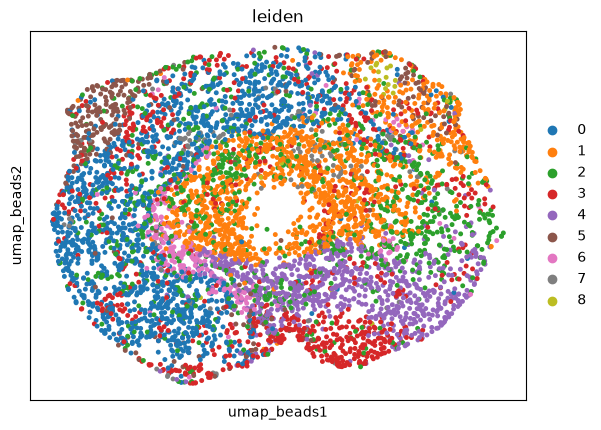

In [12]:
sc.pl.embedding(adata, basis="umap_beads", color=["leiden"], s=50)

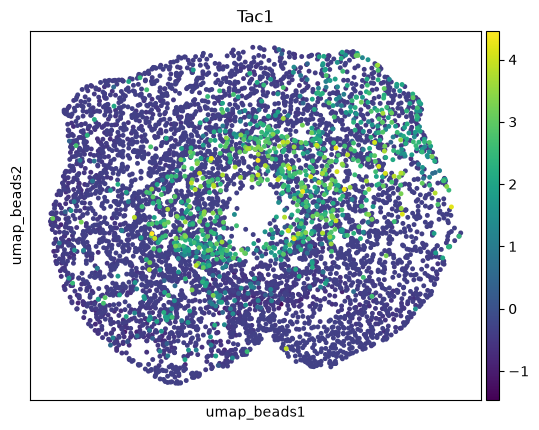

In [13]:
sc.pl.embedding(adata, basis="umap_beads", color=["Tac1"], s=50, gene_symbols="Gene_name")

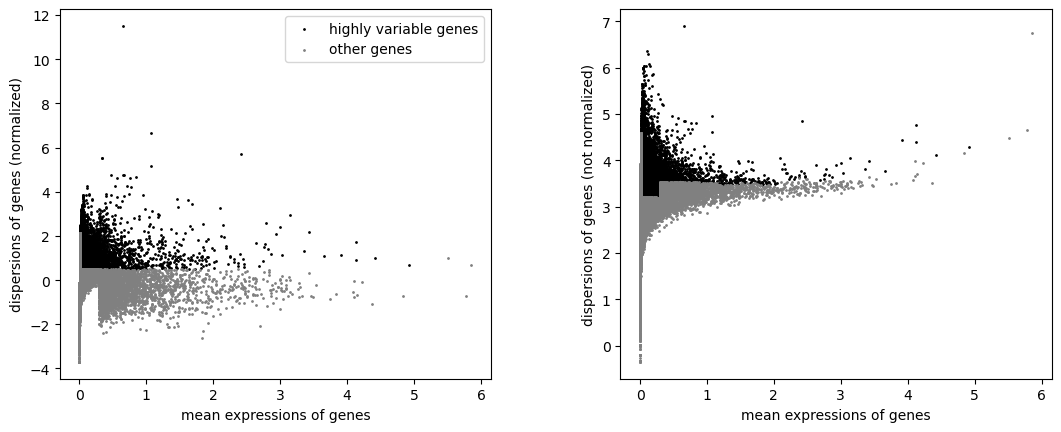

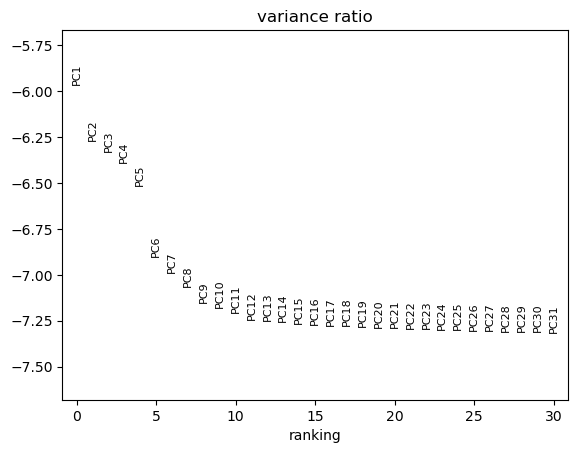

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


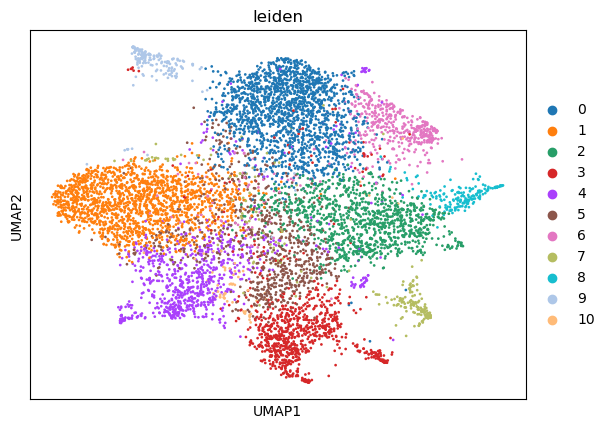

/p1/zulab_users/jtian/anaconda3/envs/my_IRISeq_py38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


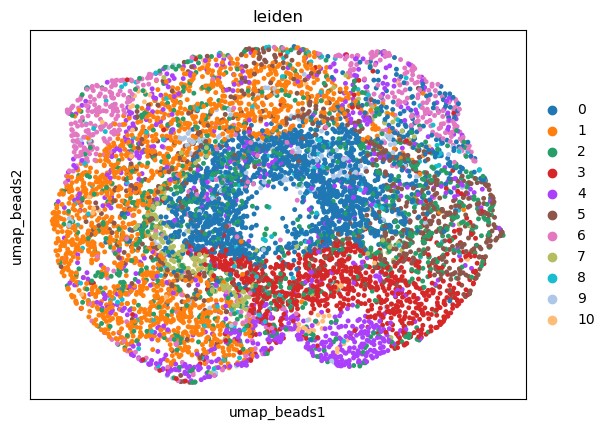

In [2]:
adata_full=sc.read_h5ad("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/cDNA/Adata/adata_full.h5ad")
adata_full.obs["receiver_barcode"] = (
    adata_full.obs.index.astype(str)
    .str.replace(r"^[^.]*\.", "", regex=True)
    .str.replace("-", "", regex=False)
)
adata_full.obs = adata_full.obs.set_index("receiver_barcode")
adata_full.var["mt"] = (
    adata_full.var["Gene_name"]
    .astype(str)
    .str.lower()
    .str.startswith("mt-")
)

sc.pp.calculate_qc_metrics(
    adata_full,
    qc_vars=["mt"],
    inplace=True
)
adata_full_raw = adata_full.copy()

sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

sc.pp.highly_variable_genes(
    adata_full,
    min_mean=0.0125,
    max_mean=5,
    min_disp=0.5,
)

sc.pl.highly_variable_genes(adata_full)

adata_full = adata_full[:, adata_full.var["highly_variable"]].copy()

sc.pp.regress_out(
    adata_full,
    ['total_counts', 'pct_counts_mt']
)

sc.pp.scale(adata_full, max_value=10)

sc.tl.pca(adata_full)
sc.pl.pca_variance_ratio(adata_full, log=True)

sc.pp.neighbors(
    adata_full,
    n_neighbors=20,
    n_pcs=30
)

sc.tl.umap(
    adata_full,
    min_dist=0,
    spread=3
)

sc.tl.leiden(
    adata_full,
    resolution=1.1
)

sc.pl.umap(
    adata_full,
    color=['leiden']
)
umap_out = Path(
    "/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/"
    "demo-FY1_3-cpugpu/gpu_beads_umap_coords.csv"
)

umap_df = pd.read_csv(
    umap_out,
    index_col="receiver_barcode",
)
merge=adata_full.obs.merge(umap_df, left_index=True, right_index=True, how='left')
adata_full.obsm['X_umap_beads'] = merge[['UMAP1', 'UMAP2']].copy().to_numpy()
adata_full.obsm['X_umap_beads']
sc.pl.embedding(adata_full, basis="umap_beads", color=["leiden"], s=50)

/tmp/ipykernel_3659774/2307263203.py:25: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_full, n_top_genes=2000, flavor='seurat_v3')#


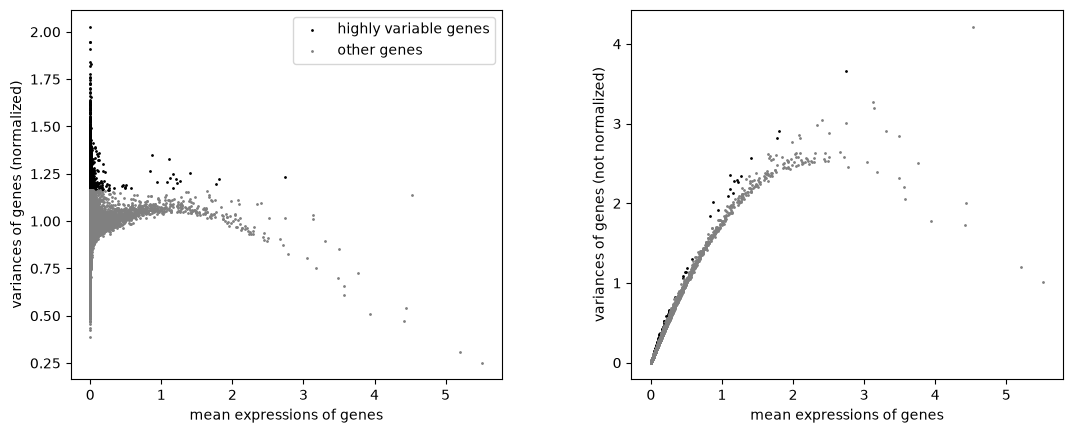

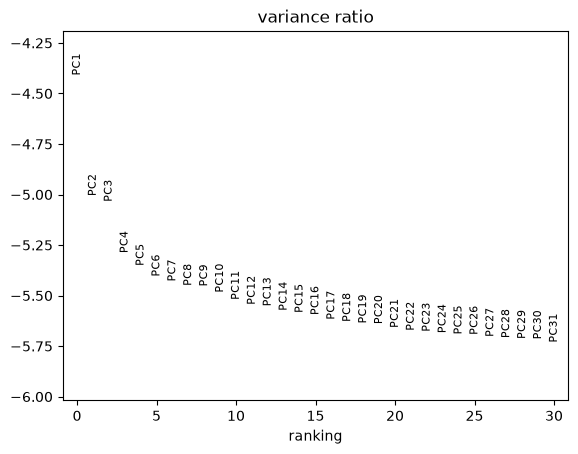

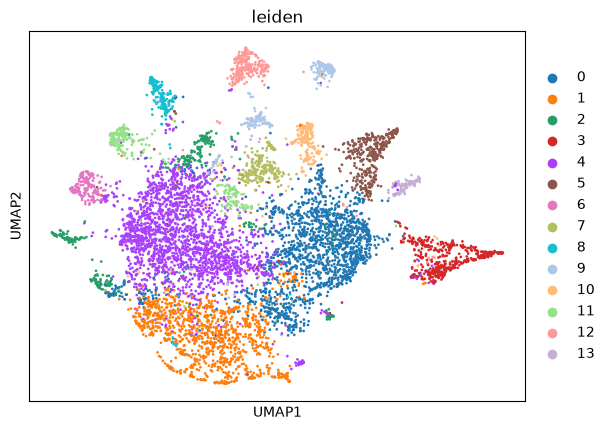

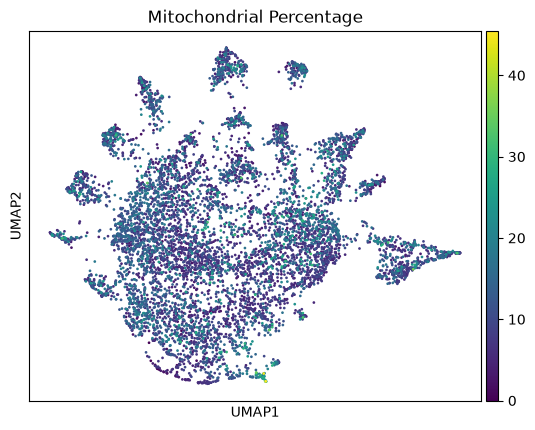

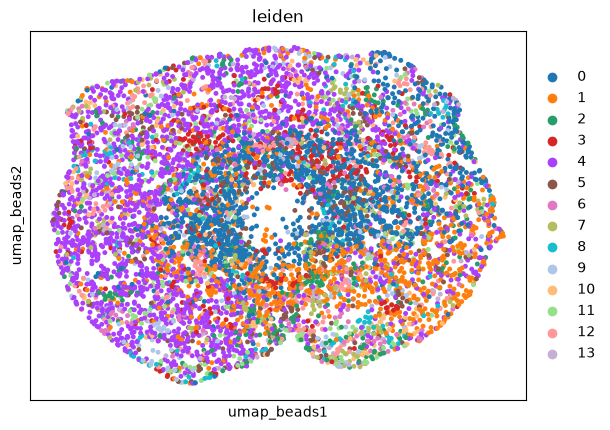

In [4]:
adata_full=sc.read_h5ad("/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/demo-FY1_3-pipeline1/cDNA/Adata/adata_full.h5ad")
adata_full.obs["receiver_barcode"] = (
    adata_full.obs.index.astype(str)
    .str.replace(r"^[^.]*\.", "", regex=True)
    .str.replace("-", "", regex=False)
)
adata_full.obs = adata_full.obs.set_index("receiver_barcode")
adata_full.var["mt"] = (
    adata_full.var["Gene_name"]
    .astype(str)
    .str.lower()
    .str.startswith("mt-")
)

sc.pp.calculate_qc_metrics(
    adata_full,
    qc_vars=["mt"],
    inplace=True
)
adata_full_raw = adata_full.copy()

sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

sc.pp.highly_variable_genes(adata_full, n_top_genes=2000, flavor='seurat_v3')#


sc.pl.highly_variable_genes(adata_full)

adata_full = adata_full[:, adata_full.var["highly_variable"]].copy()

sc.pp.regress_out(
    adata_full,
    ['total_counts', 'pct_counts_mt']
)

sc.pp.scale(adata_full, max_value=10)

sc.tl.pca(adata_full, svd_solver='arpack')#
sc.pl.pca_variance_ratio(adata_full, log=True)

sc.pp.neighbors(
    adata_full,
    n_neighbors=15,
    n_pcs=20
)#

sc.tl.umap(
    adata_full,
    min_dist=0,
    spread=3
)

sc.tl.leiden(adata_full, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)#


sc.pl.umap(
    adata_full,
    color=['leiden']
)
sc.pl.umap(adata_full, color=['pct_counts_mt'], title='Mitochondrial Percentage')
umap_out = Path(
    "/p2/zulab/jtian/data/IRISeq/demo_FY1_3/output/"
    "demo-FY1_3-cpugpu/gpu_beads_umap_coords.csv"
)

umap_df = pd.read_csv(
    umap_out,
    index_col="receiver_barcode",
)
merge=adata_full.obs.merge(umap_df, left_index=True, right_index=True, how='left')
adata_full.obsm['X_umap_beads'] = merge[['UMAP1', 'UMAP2']].copy().to_numpy()
adata_full.obsm['X_umap_beads']
sc.pl.embedding(adata_full, basis="umap_beads", color=["leiden"], s=50)